# 读取表格数据，整理数据，保存整理后的数据

Processing sheet: 511 (400 rows)
Processing sheet: 512 (400 rows)
Processing sheet: 513 (400 rows)
Processing sheet: 514 (400 rows)
Processing sheet: 515 (400 rows)
Processing sheet: 516 (400 rows)
Processing sheet: 517 (400 rows)
Processing sheet: 518 (400 rows)
Processing sheet: 522(2) (2000 rows)
Processing sheet: 523(2) (2000 rows)
Processing sheet: 524(2) (400 rows)
Processing sheet: 526(2) (400 rows)
Processing sheet: 527(2) (400 rows)
Processing sheet: 529(2) (400 rows)
Processing sheet: 530(2) (400 rows)
Processing sheet: 535 (400 rows)
Processing sheet: 601(2) (2000 rows)
Processing sheet: 602(2) (2000 rows)
Skipping empty sheet: Sheet1


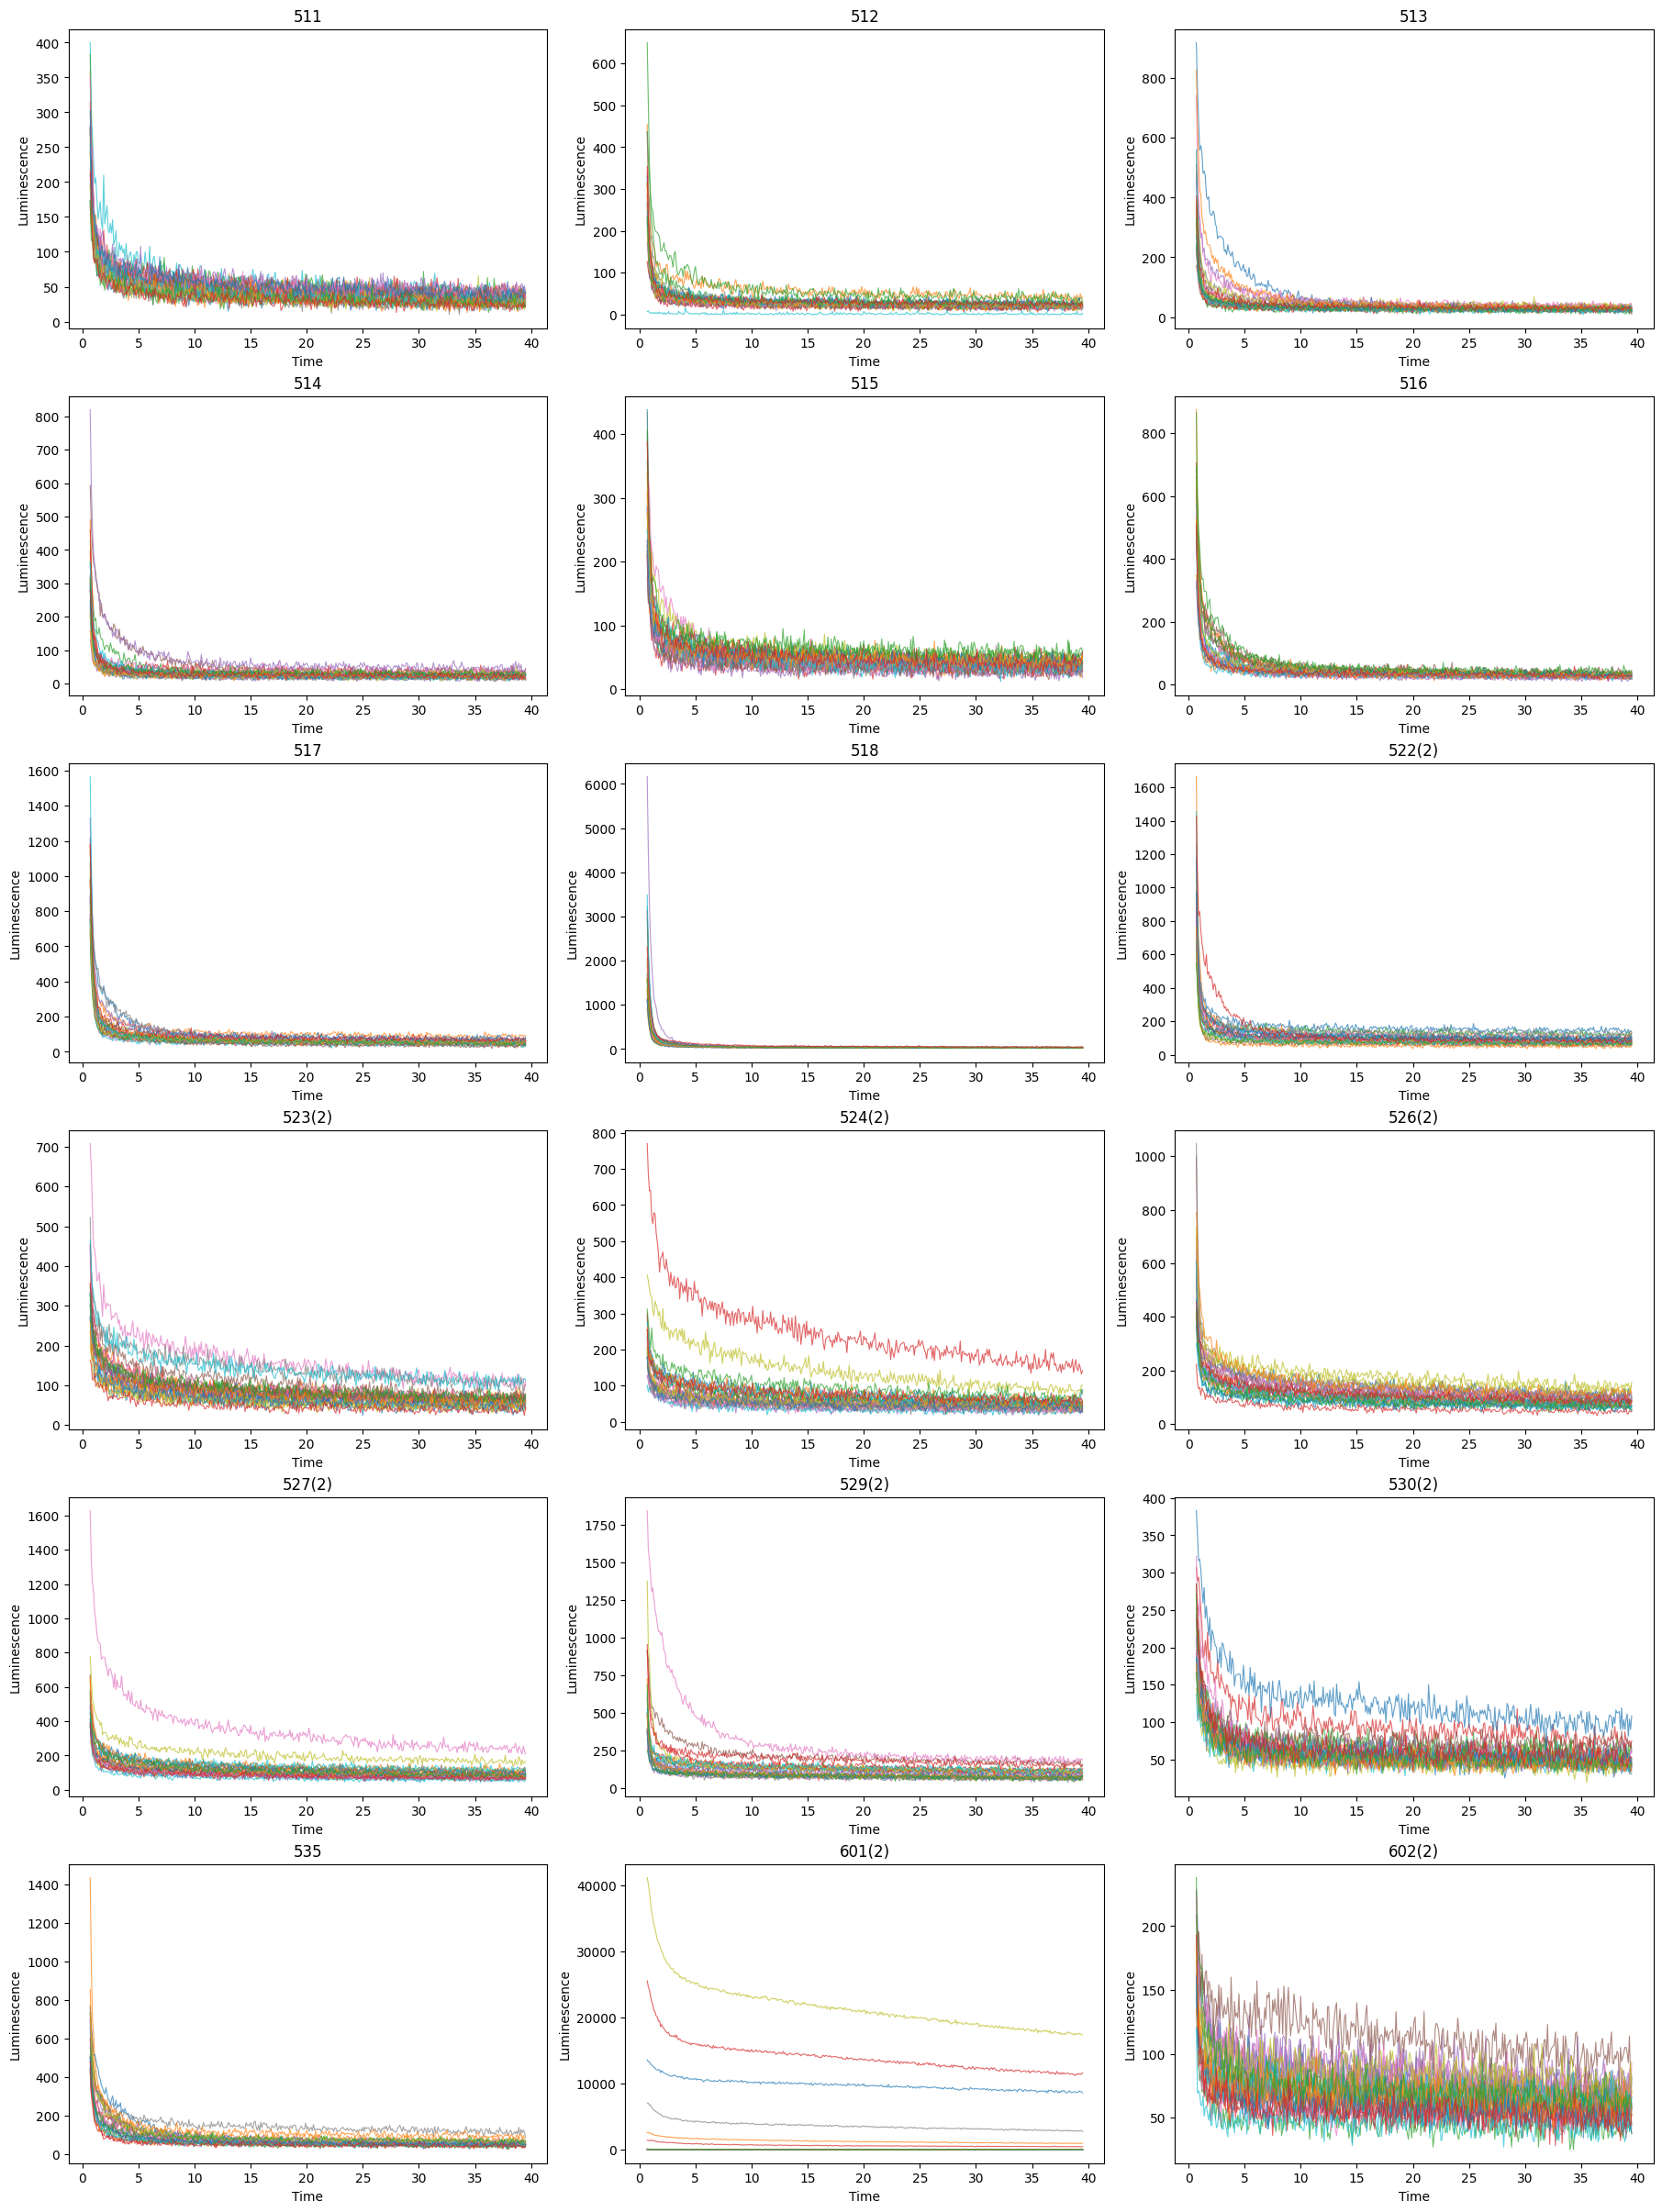

✓ processed (cropped) data saved to output\processed_new_data_ori.pkl


In [12]:
import os, pickle
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
excel_path  = 'data/New_data_20250715_M.xlsx'
output_dir  = 'output'
pickle_file = os.path.join(output_dir, 'processed_new_data_ori.pkl')
os.makedirs(output_dir, exist_ok=True)


# ------------------------------------------------------------------
# Load every sheet, clean, crop, store
# ------------------------------------------------------------------
if not os.path.exists(excel_path):
    print(f"File {excel_path} not found. Current directory contents:")
    for root, _, files in os.walk('.'):
        for f in files:
            print(os.path.join(root, f))
    raise SystemExit

sheets  = pd.read_excel(excel_path, sheet_name=None, header=None)
cleaned = {}

# for name, df in sheets.items():
#     # df_t = (
#     #     df.drop(index=0)          # drop the textual first row
#     #       .reset_index(drop=True)
#     #       .T                      # transpose
#     # )
#     # drop the first and second row

#     df_t = df.drop(index=[0, 1]).reset_index(drop=True).T


for name, df in sheets.items():
    # ─── 1. Skip blank worksheets ───
    if df.empty:
        print(f"Skipping empty sheet: {name}")
        continue

    # ─── 2. Safely drop the first two rows and transpose ───
    df_t = (
        df        # original
        .drop(index=df.index[:2], errors="ignore")  # only drop if present
        .reset_index(drop=True)
        .T                                          # transpose
    )

    # … (rest of your loop is unchanged) 

    df_t.columns = df_t.iloc[0]   # promote first transposed row to header
    df_t = df_t.drop(index=0).reset_index(drop=True)
    # rename column 'datapoint' to 'Time_index' if it exists
    if 'datapoint' in df_t.columns:
        df_t = df_t.rename(columns={'datapoint': 'Time_index'})

    # ensure numeric dtypes
    df_t = df_t.apply(pd.to_numeric, errors='ignore')

    # print the current sheet No.
    print(f'Processing sheet: {name} ({len(df_t)} rows)')



    # -------- CROP: keep Time_index in [7, 395] -------------------
    mask  = (df_t['Time_index'] >= 7) & (df_t['Time_index'] <= 395)
    df_t  = df_t.loc[mask].reset_index(drop=True)

    cleaned[name] = df_t

# ------------------------------------------------------------------
# Quick-look plot: 3 × 3 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(6, 3, figsize=(18, 24), layout='constrained')
axes = axes.ravel()

for ax, (name, df_t) in zip(axes, cleaned.items()):
    time    = df_t['Time'].astype(float).values
    slices  = df_t.drop(columns=['Time_index', 'Time'])

    ax.plot(time, slices.values, lw=0.8, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('Time')
    ax.set_ylabel('Luminescence')

# remove unused panes if < 9 sheets
for ax in axes[len(cleaned):]:
    ax.remove()

plt.show()

# ------------------------------------------------------------------
# Pickle the cropped data
# ------------------------------------------------------------------
with open(pickle_file, 'wb') as f:
    pickle.dump(cleaned, f)

print(f'✓ processed (cropped) data saved to {pickle_file}')


# 发现数据方差太大了影响分析，先进行对数变换，保存变换后的数据

Sheet 512: dropped 1 low-count slice(s)
Skipping empty sheet: Sheet1


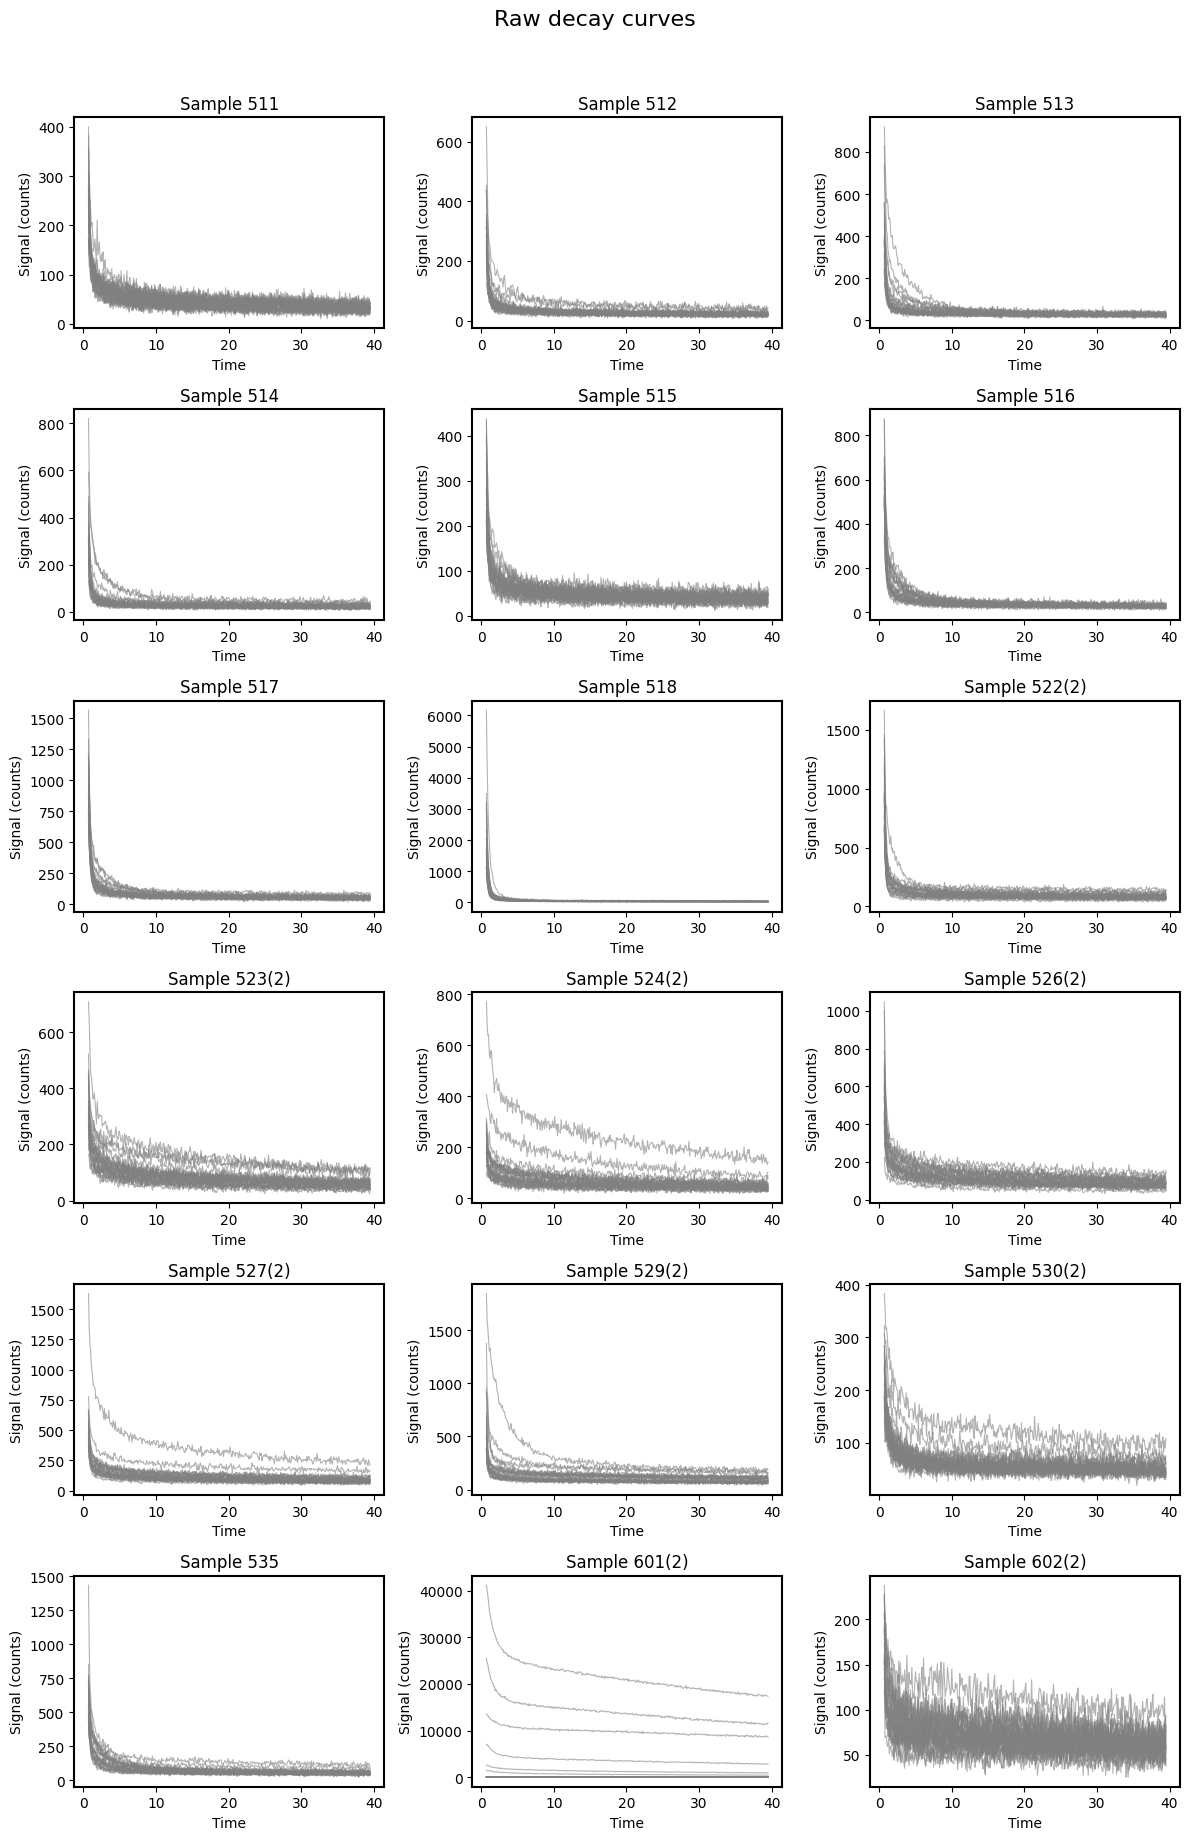

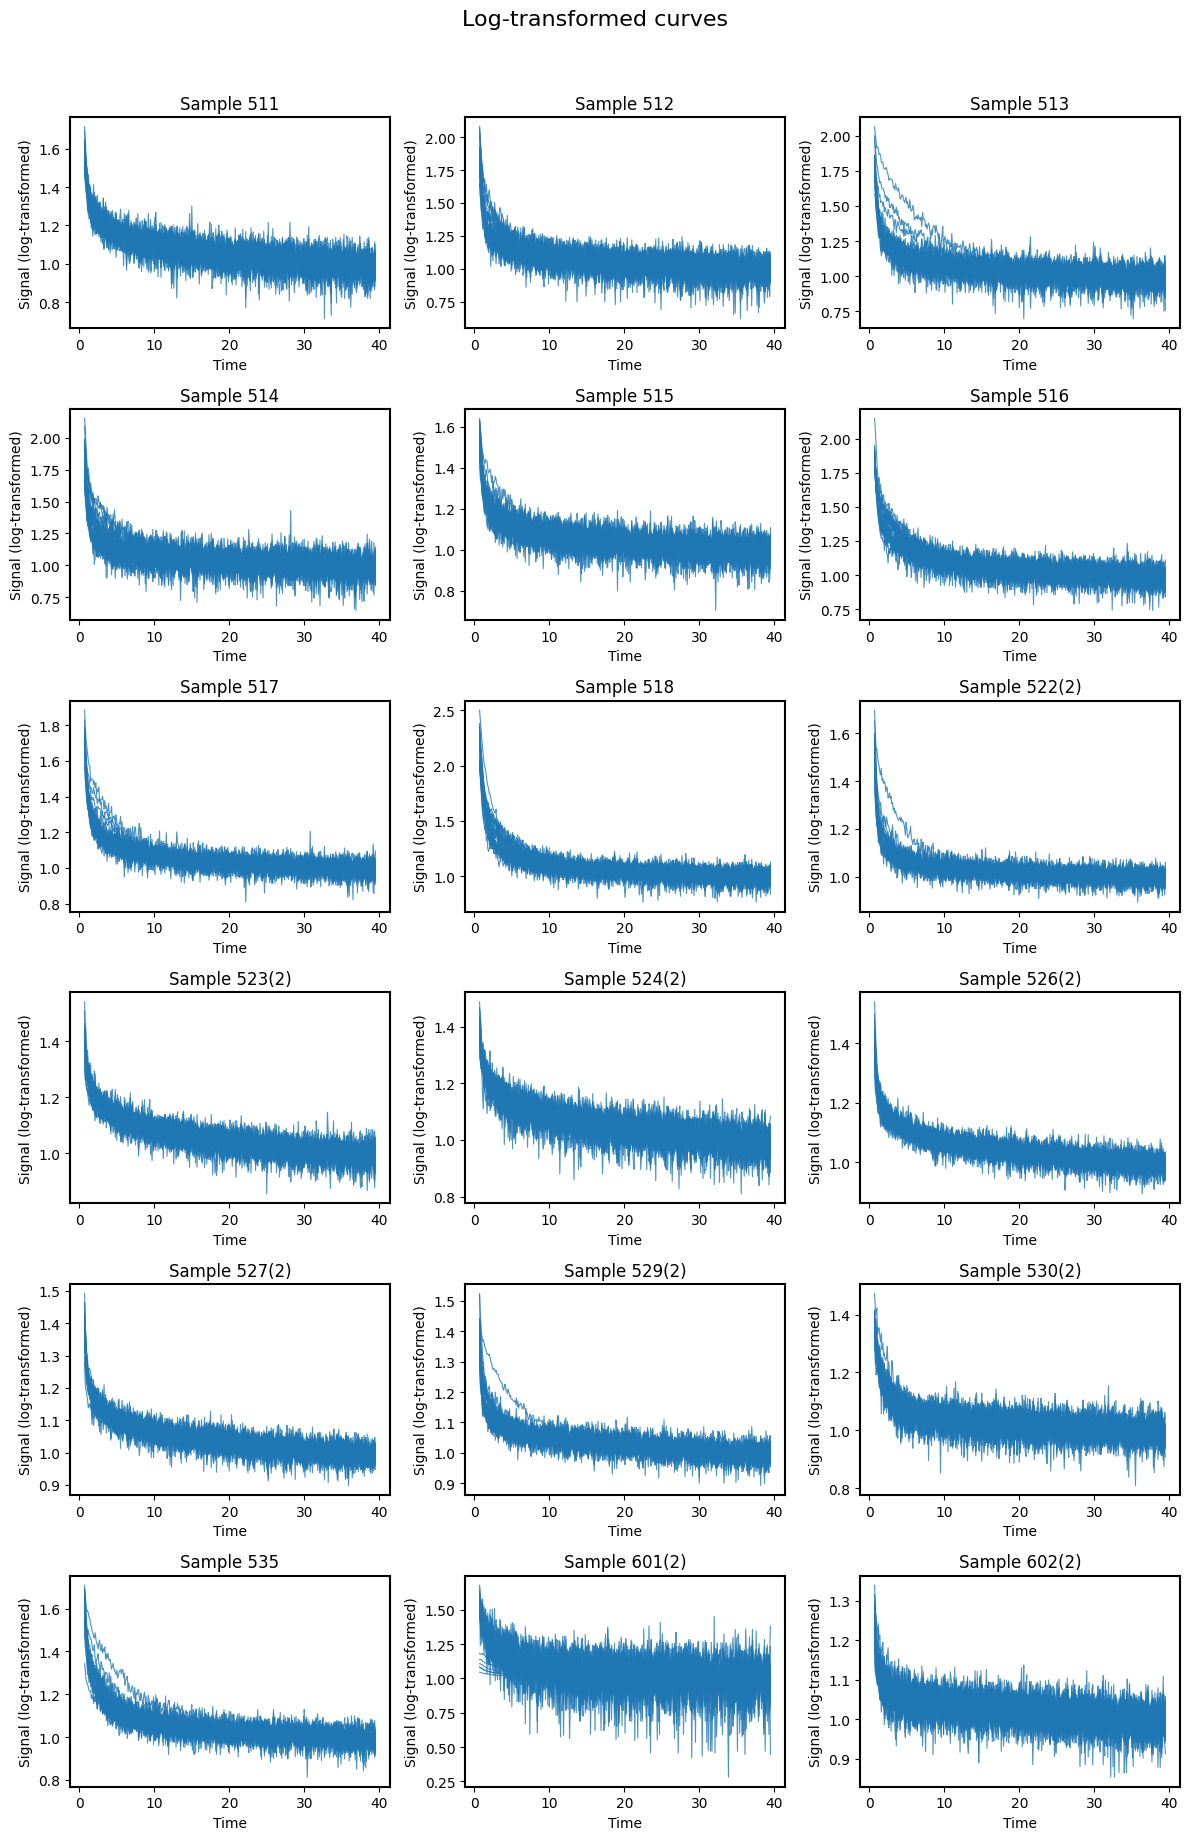

✓ raw & log-transformed data saved to output\processed_new_data_log.pkl


In [14]:
import os, pickle, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
excel_path  = 'data/New_data_20250715_M.xlsx'
output_dir  = 'output'
pickle_file = os.path.join(output_dir, 'processed_new_data_log.pkl')
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------------
# 1.  Load sheets, clean, crop 7 ≤ Time_index ≤ 395
# ------------------------------------------------------------------
if not os.path.exists(excel_path):
    raise FileNotFoundError(f'{excel_path} not found!')

sheets   = pd.read_excel(excel_path, sheet_name=None, header=None)


raw_dict, log_dict = {}, {}



for name, df in sheets.items():
    # ─── 1. Skip blank worksheets ───
    if df.empty:
        print(f"Skipping empty sheet: {name}")
        continue

    # ─── 2. Safely drop the first two rows and transpose ───
    df_t = (
        df        # original
        .drop(index=df.index[:2], errors="ignore")  # only drop if present
        .reset_index(drop=True)
        .T                                          # transpose
    )

    # … (rest of your loop is unchanged) 

    df_t.columns = df_t.iloc[0]   # promote first transposed row to header
    df_t = df_t.drop(index=0).reset_index(drop=True)
    # rename column 'datapoint' to 'Time_index' if it exists
    if 'datapoint' in df_t.columns:
        df_t = df_t.rename(columns={'datapoint': 'Time_index'})

    # df_t.columns = df_t.iloc[0]
    # df_t = df_t.drop(index=0).reset_index(drop=True)
    df_t = df_t.apply(pd.to_numeric, errors='ignore')

    mask  = (df_t['Time_index'] >= 7) & (df_t['Time_index'] <= 395)
    df_t  = df_t.loc[mask].reset_index(drop=True)

    # ── log10 transform the slice columns only ───────────────────
    slice_cols = df_t.columns.difference(['Time_index', 'Time'])
    df_log = df_t.copy()
    df_log[slice_cols] = np.log10(df_log[slice_cols] + 1e-9)
    # df_log[slice_cols] = np.log(df_log[slice_cols] + 1e-9)   # base-e log

    # ── filter: keep slices whose entire log curve ≥ 0 ───────────
    good_cols = [
        c for c in slice_cols
        if (df_log[c] >= 0).all()
    ]
    n_dropped = len(slice_cols) - len(good_cols)
    if n_dropped:
        print(f'Sheet {name}: dropped {n_dropped} low-count slice(s)')

    # ── NORMALISE each good slice by mean of its last 100 values ─
    for col in good_cols:
        tail_mean = df_log[col].iloc[-100:].mean()  # fewer rows → uses all
        if tail_mean != 0:                          # guard against zero just in case
            df_log[col] /= tail_mean

    keep_cols = ['Time_index', 'Time'] + good_cols
    raw_dict[name] = df_t[keep_cols].copy()
    log_dict[name] = df_log[keep_cols].copy()



# # crop the log_dict for time <=150
# for name, df in log_dict.items():
#     mask  = (df['Time_index'] <= 200)
#     df_t  = df.loc[mask].reset_index(drop=True)
#     log_dict[name] = df_t.copy()


# ------------------------------------------------------------------
# 2.  Quick-look plot : raw vs. log
# ------------------------------------------------------------------
def plot_grid(data_dict, title_suffix, y_label, line_kw, colour='C0'):
    fig, axes = plt.subplots(6, 3, figsize=(12, 18))
    axes = axes.ravel()

    for ax, (name, df) in zip(axes, data_dict.items()):
        t   = df['Time'].astype(float).values
        y   = df.drop(columns=['Time_index', 'Time']).values

        ax.plot(t, y, **line_kw, color=colour)
        ax.set_title(f'Sample {name}')
        ax.set_xlabel('Time')
        ax.set_ylabel(y_label)



        # set the line widthe of spines to 1.5
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    for ax in axes[len(data_dict):]:
        ax.axis('off')

    fig.suptitle(title_suffix, fontsize=16, y=1.02)
    fig.tight_layout()
    return fig

fig1=plot_grid(raw_dict, 'Raw decay curves', 'Signal (counts)',dict(lw=0.8, alpha=0.6), colour='grey')
fig2=plot_grid(log_dict, 'Log-transformed curves', 'Signal (log-transformed)',dict(lw=0.8, alpha=0.8))
plt.show()

fig1.savefig('Figures/ori_decade_curve.png', dpi=600, bbox_inches='tight')
fig1.savefig('Figures/ori_decade_curve.pdf', dpi=600, bbox_inches='tight')

fig2.savefig('Figures/log_decade_curve.png', dpi=600, bbox_inches='tight')
fig2.savefig('Figures/log_decade_curve.pdf', dpi=600, bbox_inches='tight')

# ------------------------------------------------------------------
# 3.  Pickle both data sets
# ------------------------------------------------------------------
with open(pickle_file, 'wb') as f:
    pickle.dump(log_dict, f)

print(f'✓ raw & log-transformed data saved to {pickle_file}')
